# Pipeline de stacking pondéré des raies de recombinaison radio (RRL α de CI).
 
## Étapes principales :
1. Chargement du spectre complet (fichier FITS alltime)
2. Extraction de chaque transition individuelle dans une fenêtre fréquentielle
3. Évaluation du rapport signal/bruit (S/N) de chaque raie isolée
4. Définition des intervalles de stacking (plages en nombre quantique n)
5. Stacking pondéré avec rejection des raies contaminées (critère S/N)
6. Sauvegarde des stacks et visualisation mosaïque
 
### Dépendances : numpy, matplotlib, astropy, scipy, tqdm, calcul (local), graphics (local)



In [2]:
%matplotlib widget

In [3]:
# ---------------------------------------------------------------------------
# 0. Imports & configuration graphique
# ---------------------------------------------------------------------------
import sys
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.modeling.models import Voigt1D
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import linregress
from tqdm import tqdm
import astropy.units as u
 
# Modules locaux (répertoire ../../Codes)
# sys.path management removed — install with: pip install -e .
import spectral_tools.tools as tools
import spectral_tools.graphics as graphics
 
matplotlib.rcParams.update({
    'mathtext.fontset':      'stix',
    'font.family':           'serif',
    'font.size':             17,
    'axes.linewidth':        2.5,
    'lines.linewidth':       1.7,
    'xtick.direction':       'in',
    'ytick.direction':       'in',
    'xtick.labelsize':       13,
    'ytick.labelsize':       13,
    'xtick.major.size':      5,
    'xtick.major.width':     1,
    'xtick.minor.size':      4.5,
    'xtick.minor.width':     1,
    'ytick.major.size':      4.5,
    'ytick.major.width':     1,
    'ytick.minor.size':      3.5,
    'ytick.minor.width':     1,
})
 


In [4]:
# ---------------------------------------------------------------------------
# 1. Paramètres utilisateur
# ---------------------------------------------------------------------------
SOURCE   = "TAUA_CLOUDS"   # identifiant de la source ("TAU_A", "TAUA_CLOUDS", …)
MY_LINE  = "Calph"          # type de raie (Calph, …)
OFF      = True             # True → utilise le spectre OFF
 
OFF_STR  = '_OFF' if OFF else ''
OG       = 1e4              # facteur de normalisation de l'opacité
WIDTH    = 1000             # demi-largeur de la fenêtre d'extraction (canaux)
VELO_SYS = 0                # vitesse systémique autour de laquelle centrer (Hz)
 
# Intervalles de stacking (nombre quantique) : [pas pour n<n0, n0–n1, n>n1]
QI = [40, 20, 50]
N0_STACK = 500
N1_STACK = 730
 
# Critère S/N pour la rejection des raies contaminées
SNR_THRESHOLD_LOW  = 0.0    # raies en émission (S/N < 0 → contaminé)
SNR_THRESHOLD_HIGH = 0.8    # raies trop faibles / bruitées
 
PATH_FITS     = f'alltime_files/alltime_{SOURCE}_{MY_LINE}{OFF_STR}.fits'
PATH_LINES    = '../../Codes/rrlines.csv'
PATH_STACKS   = f'stacks/STACKS-{SOURCE}{OFF_STR}.txt'
 


In [5]:
# ---------------------------------------------------------------------------
# 2. Chargement du spectre FITS
# ---------------------------------------------------------------------------
full_spectrum = fits.open(PATH_FITS)
 
# Récupération de l'axe fréquentiel depuis l'en-tête WCS
hdr   = full_spectrum[0].header
CRVAL = hdr['CRVAL3']
CDELT = hdr['CDELT3']
CRPIX = hdr['CRPIX3']
NAXIS = hdr['NAXIS3']
df    = CDELT   # résolution spectrale (Hz/canal)
 
I   = full_spectrum[0].data[:, 0, 0]   # spectre d'intensité
RMS = full_spectrum[2].data[:, 0, 0]   # carte RMS associée
f   = np.array([CRVAL + (i - CRPIX) * CDELT for i in range(NAXIS)])   # axe fréq.
 
# Récupération des transitions dans la bande [fmin, fmax]
# On limite à la lane 0 : fmax fixé à 47.56 GHz
fmini  = hdr["FMIN"]
fmaxi  = 47.55859375   # borne supérieure de la lane 0 (GHz)
Lines  = tools.get_line(fmini, fmaxi, VELO_SYS, line=MY_LINE, path=PATH_LINES)
 
lowest_n  = int(np.min(Lines.index))
highest_n = int(np.min((np.max(Lines.index), 850)))
 


In [6]:
# ---------------------------------------------------------------------------
# 3. Extraction des raies individuelles
# ---------------------------------------------------------------------------
# Fenêtre fréquentielle de référence (centrée sur 0)
slice_freq_window = np.linspace(-df * (WIDTH // 2), df * (WIDTH // 2), WIDTH)
FREF = np.copy(slice_freq_window)
 
isolated_lines   = []
weights_of_lines = []
 
# Paramètres de calibration du bruit
CAP_CALIB   = True    # plafonne le RMS pour éviter une sur-pondération
VAL_MAX_SNR = 6       # S/N maximal autorisé avant écrêtage du RMS
 
for i in range(max(lowest_n, 426), min(highest_n, 850)):
    f0 = Lines.loc[i]
 
    # Raie hors bande → on l'ignore
    if f0 < f[0] or f0 > f[-1]:
        continue
 
    slicedline = tools.slice_line(f0, I, f, cut_width=WIDTH // 2)
 
    # --- Correction brute : mise à zéro des canaux aberrants ---
    slicedline[np.isnan(slicedline)] = 0
    slicedline[np.abs(slicedline) > 100 / OG] = 0
 
    # Raie trop lacunaire (>40 % de canaux nuls) → rejetée
    if len(slicedline[slicedline == 0]) / len(slicedline) > 0.4:
        isolated_lines.append(np.full(len(slicedline), np.nan))
        weights_of_lines.append(np.nan)
        continue
 
    slicedline[slicedline == 0] = np.nan
    isolated_lines.append(slicedline)
 
    # --- Calcul du poids (1/RMS²), avec écrêtage optionnel ---
    slicedrms = np.nanmean(tools.slice_line(f0, RMS, f, cut_width=WIDTH // 2))
    if CAP_CALIB:
        signal    = np.nanmin(slicedline)
        rms_min   = signal / VAL_MAX_SNR   # RMS minimal pour que S/N ≤ VAL_MAX_SNR
        slicedrms = max(slicedrms, rms_min)
 
    weights_of_lines.append(1 / slicedrms**2)
 
# Sauvegarde des tableaux originaux avant tout filtrage
CONVOS_tot          = None   # (non utilisé dans la branche newcorr)
weights_of_lines_tot = np.array(weights_of_lines, dtype=object)
isolated_lines_tot   = np.array(isolated_lines,   dtype=object)
 


In [7]:
# ---------------------------------------------------------------------------
# 4. Évaluation du S/N de chaque raie individuelle
# ---------------------------------------------------------------------------
SNRs_all = []
for i in range(highest_n - lowest_n):
    line     = np.copy(isolated_lines[i])
    signal   = np.nanmean(line[WIDTH // 3 : 2 * WIDTH // 3])
    # Le bruit est estimé sur les ailes (hors de la fenêtre centrale)
    maskline = np.copy(line)
    maskline[WIDTH // 6 : 5 * WIDTH // 6] = np.nan
    noise    = np.nanstd(maskline)
    SNRs_all.append(-signal / noise)   # signe négatif car l'absorption est négative
 
# ---------------------------------------------------------------------------
# 5. Définition des intervalles de stacking
# ---------------------------------------------------------------------------
def build_quantum_intervals(lowest_n, highest_n, qi, n0, n1):
    """
    Construit les bornes des intervalles de stacking avec trois pas distincts :
    - qi[0] pour n ∈ [lowest_n, n0]
    - qi[1] pour n ∈ [n0, n1]
    - qi[2] pour n ∈ [n1, highest_n]
    """
    q0 = [int(i) for i in range(lowest_n, n0 + qi[0], qi[0])]
    q1 = [int(i) for i in range(q0.pop(-1), n1 + qi[1], qi[1])]
    q2 = [int(i) for i in range(q1.pop(-1), highest_n + 1, qi[2])]
    return np.array(q0 + q1 + q2, dtype=int)
 
quantum_intervals = build_quantum_intervals(lowest_n, highest_n, QI, N0_STACK, N1_STACK)
nstacks = len(quantum_intervals) - 1
print(f"Intervalles de stacking : {quantum_intervals}")
print(f"Nombre de stacks : {nstacks}")
 


Intervalles de stacking : [517 537 557 577 597 617 637 657 677 697 717 737 787 837]
Nombre de stacks : 13


/tmp/ipykernel_228841/1056504281.py:7: RuntimeWarning: Mean of empty slice
  signal   = np.nanmean(line[WIDTH // 3 : 2 * WIDTH // 3])
/home/cros/anaconda3/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [8]:
# ---------------------------------------------------------------------------
# 6. Stacking pondéré avec rejection par S/N
# ---------------------------------------------------------------------------
STACKS = []
 
for k in tqdm(range(nstacks), desc="Stacking"):
    N0_k = quantum_intervals[k]
    N_k  = quantum_intervals[k + 1]
 
    # Indices locaux dans les tableaux pré-calculés
    idx_start = N0_k - lowest_n
    idx_end   = N_k  - lowest_n
 
    weights = np.array(weights_of_lines_tot[idx_start:idx_end], dtype=float)
    stack_slice = np.array(list(isolated_lines_tot[idx_start:idx_end]), dtype=float)
 
    # --- Rejection des raies contaminées (critère S/N) ---
    for n_idx in range(N0_k, N_k):
        ni = n_idx - lowest_n
        snr = SNRs_all[ni]
        local_idx = n_idx - N0_k
        if snr > SNR_THRESHOLD_HIGH or snr < SNR_THRESHOLD_LOW:
            weights[local_idx] = np.nan   # raie exclue du stack
 
    # --- Moyenne pondérée ---
    norm = np.nansum(weights)
    weighted = np.copy(stack_slice)
    for i in range(len(weighted)):
        weighted[i] = weighted[i] * weights[i] / norm
 
    STACKS.append(np.nansum(weighted, axis=0))
 
STACKS = np.array(STACKS)


Stacking: 100%|████████████████████████████████| 13/13 [00:00<00:00, 295.81it/s]


In [9]:
# ---------------------------------------------------------------------------
# 7. Sauvegarde
# ---------------------------------------------------------------------------
qbounds = np.column_stack([quantum_intervals[:-1], quantum_intervals[1:]])
np.savetxt(PATH_STACKS, np.concatenate((qbounds, STACKS), axis=1))
print(f"Stacks sauvegardés : {PATH_STACKS}")


Stacks sauvegardés : stacks/STACKS-TAUA_CLOUDS_OFF.txt


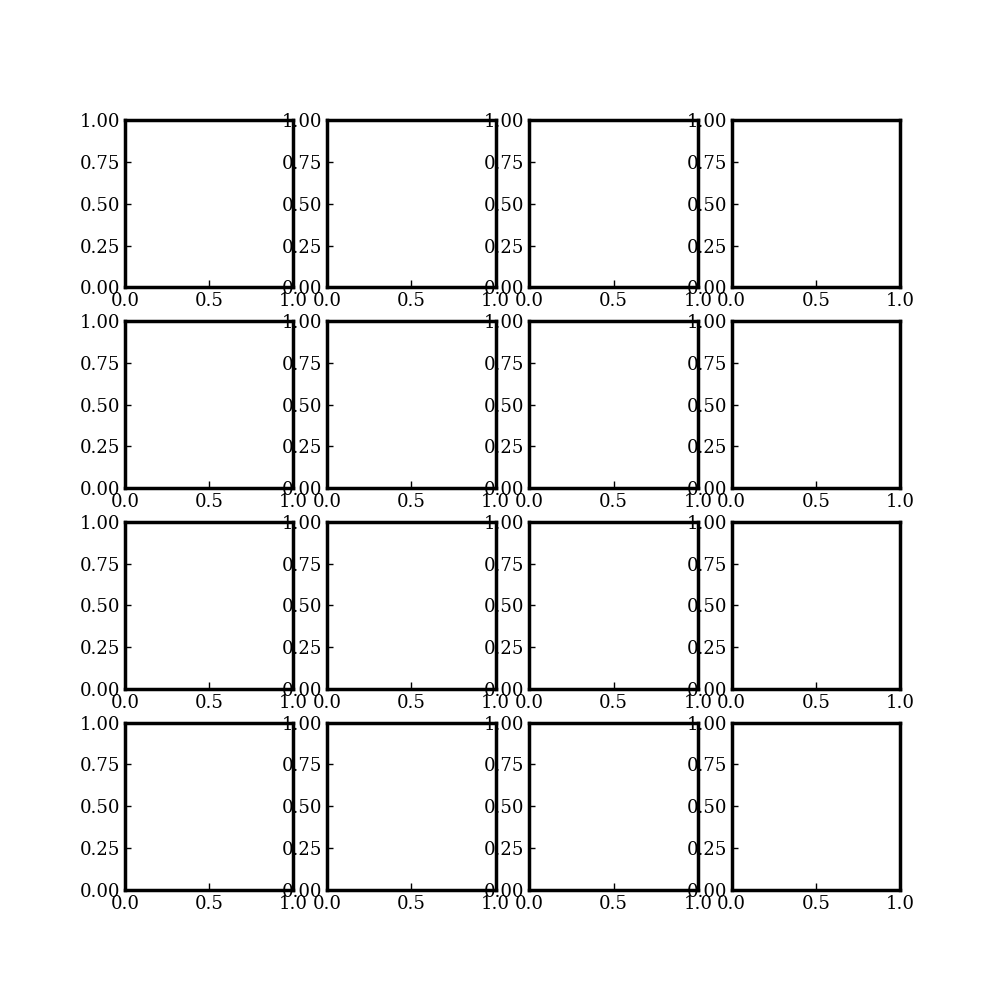

In [11]:
# ---------------------------------------------------------------------------
# 8. Visualisation mosaïque des stacks
# ---------------------------------------------------------------------------
SLOT = 4   # facteur de rebinning spectral
 
figmosaic, axmosaic = plt.subplots(
    int(np.ceil(nstacks / 4)),
    4,
    figsize=(10, 10)
)
 

In [23]:
for k in range(nstacks):
    ax  = axmosaic.flatten()[k]
    ax.clear()
    N0_k, N_k = quantum_intervals[k], quantum_intervals[k + 1]
    f0  = 0.5 * (tools.line_freq(N0_k) + tools.line_freq(N_k))
 
    line, xaxis = tools.rebinning(STACKS[k], FREF * 1000, SLOT)   # xaxis en kHz
 
    graphics.set_axes(ax, pad=5)
    ax.text(
        0.05, 0.05,
        f"C$\\alpha$({0.5*(quantum_intervals[k]+quantum_intervals[k+1]):.0f})\n{f0:.2f}",
        transform=ax.transAxes, va='bottom', ha='left'
    )
    ax.plot(xaxis, line * 1e4, c='k')
    ax.set_xlim(-49, 49)
    ax.set_ylim(-7, 1.9)
 
    if k % 4 > 0:
        ax.set_yticklabels([])
    if k < (nstacks // 4 - 1) * 4:
        ax.set_xticklabels([])
 
figmosaic.supylabel(r'$\tau \times 10^{-4}$')
figmosaic.supxlabel(r'Doppler shift $f-f_{n+1\longrightarrow n}$ (kHz)')
figmosaic.tight_layout()
figmosaic.subplots_adjust(hspace=0, wspace=0)

for i in range(axmosaic.flatten().shape[0] - nstacks,0,-1) :
    ax = axmosaic.flatten()[-i]
    ax.set_axis_off()


In [ ]:
figmosaic.savefig(f"{SOURCE}{OFF_STR}-detections.pdf")